In [17]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [20]:
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import seaborn as sns
from src.model.lightning import MathLightningModule
from src.data.tokenizer import CharTokenizer

In [19]:
ckpt_path = r"C:\Users\ravik\Math-transformer\checkpoints\math-transformer-epoch=06-val_loss=0.00.ckpt"
tokenizer = CharTokenizer()
model = MathLightningModule.load_from_checkpoint(
    ckpt_path, vocab_size=tokenizer.vocab_size, pad_token_id=tokenizer.pad_token_id
)
model.eval()
device = model.device

C:\Users\ravik\Math-transformer\venv\Lib\site-packages\torch\nn\modules\transformer.py:143: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


In [21]:
attention_map = {}

# Target the cross-attention mechanism of the final decoder layer
target_mha = model.model.transformer.decoder.layers[-1].multihead_attn

# PyTorch hardcodes need_weights=False internally. We intercept the forward pass to force it True.
original_forward = target_mha.forward


def forward_with_weights(*args, **kwargs):
    kwargs["need_weights"] = True
    return original_forward(*args, **kwargs)


target_mha.forward = forward_with_weights


def get_attention(name):
    def hook(module, input, output):
        attention_map[name] = output[1].detach().cpu().squeeze(0)

    return hook


target_layer = model.model.transformer.decoder.layers[-1].multihead_attn
hook_handle = target_layer.register_forward_hook(get_attention("cross_attention"))

In [22]:
equation = "99+15="
answer_reversed = "114"[::-1]  # "411"

# Encode characters to tensors
src_ids = (
    [tokenizer.sos_token_id] + tokenizer.encode(equation) + [tokenizer.eos_token_id]
)
tgt_ids = (
    [tokenizer.sos_token_id]
    + tokenizer.encode(answer_reversed)
    + [tokenizer.eos_token_id]
)

src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(1).to(device)
tgt_tensor = torch.tensor(tgt_ids, dtype=torch.long).unsqueeze(1).to(device)

In [23]:
# Run a Forward Pass (This triggers our wiretap)
with torch.no_grad():
    model(src_tensor, tgt_tensor)

C:\Users\ravik\Math-transformer\venv\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


In [24]:
attn_matrix = attention_map["cross_attention"].numpy()

# Create labels for our axes
src_labels = ["<sos>"] + list(equation) + ["<eos>"]
shifted_tgt_labels = list(answer_reversed) + ["<eos>", "<pad>"]

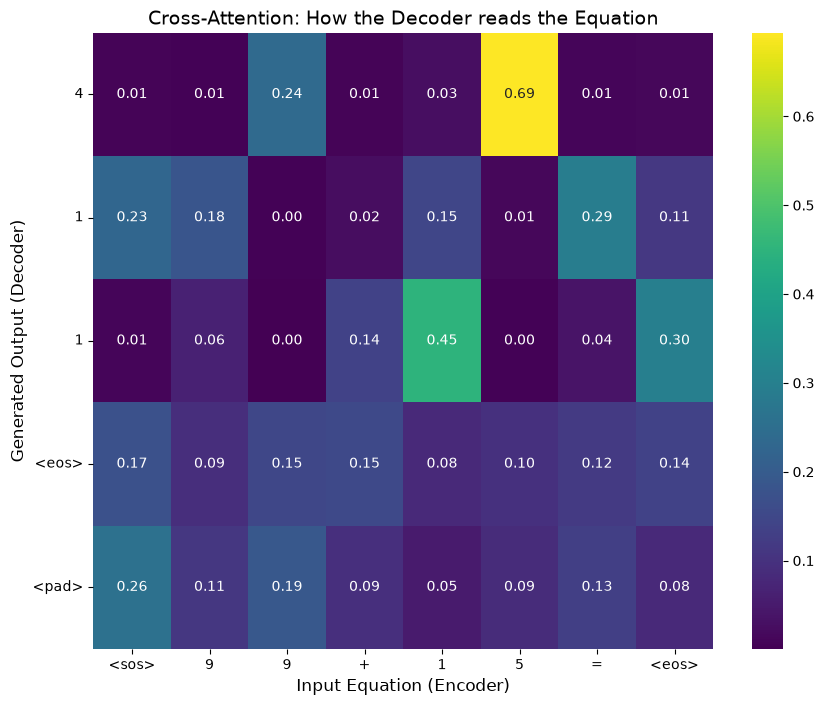

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    attn_matrix,
    xticklabels=src_labels,
    yticklabels=shifted_tgt_labels,
    cmap="viridis",
    annot=True,
    fmt=".2f",
)

plt.title("Cross-Attention: How the Decoder reads the Equation", fontsize=14)
plt.xlabel("Input Equation (Encoder)", fontsize=12)
plt.ylabel("Generated Output (Decoder)", fontsize=12)
plt.yticks(rotation=0)
plt.show()

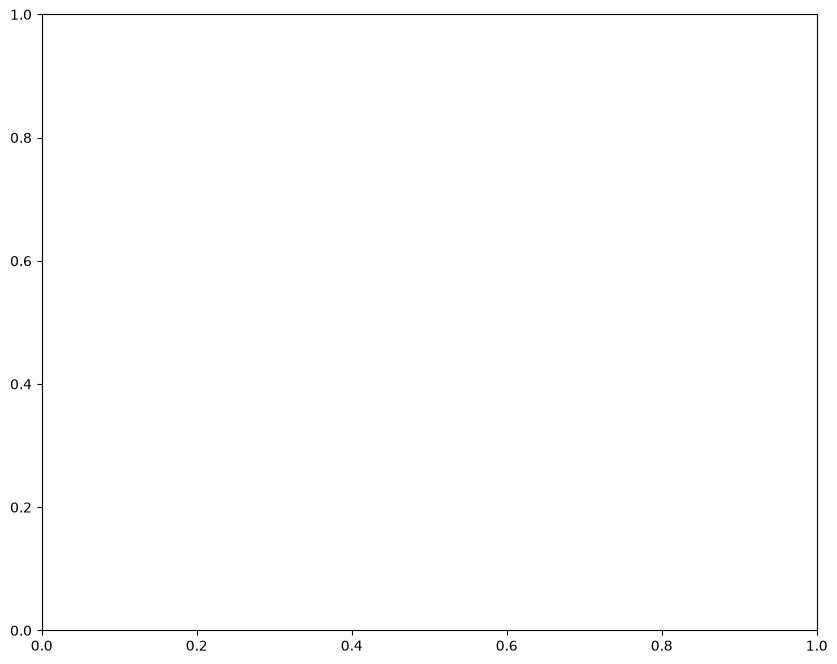

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))


def update(frame):
    """This function draws a single frame of the animation."""
    ax.clear()

    # Slice the matrix to only show the rows up to the current step
    current_matrix = attn_matrix[:frame, :]
    current_yticklabels = shifted_tgt_labels[:frame]

    # We lock vmin=0 and vmax=1 so the color scale doesn't flicker between frames
    sns.heatmap(
        current_matrix,
        xticklabels=src_labels,
        yticklabels=current_yticklabels,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=ax,
        cbar=False,
        vmin=0,
        vmax=1,
    )

    # Dynamic title that updates to show what the model is currently predicting
    predicted_char = shifted_tgt_labels[frame - 1]
    ax.set_title(
        f"Step {frame}: Model focuses on input to predict '{predicted_char}'",
        fontsize=14,
    )
    ax.set_xlabel("Input Equation (Encoder)", fontsize=12)
    ax.set_ylabel("Generated Output", fontsize=12)
    ax.tick_params(axis="y", rotation=0)

In [27]:
# 3. Create the animation (1 frame per row in the attention matrix)
num_steps = attn_matrix.shape[0]
anim = FuncAnimation(
    fig, update, frames=range(1, num_steps + 1), interval=1200
)  # 1.2 seconds per frame

# 4. Save it as a GIF in your project folder
gif_path = "attention_decoding.gif"
anim.save(gif_path, writer="pillow")
print(f"✅ Animation saved successfully to {gif_path}")

# If you want to view it directly in the Jupyter Notebook:
plt.close()  # Prevents a static duplicate from rendering
HTML(f'<img src="{gif_path}">')

✅ Animation saved successfully to attention_decoding.gif
